# ✈️ 02. Feature Engineering & Multi-Dimensional Scoring Framework
### United Airlines Skyhack Operational Intelligence System

---

## 📌 Executive Summary
In this notebook, we transform raw multi-level flight, passenger, and baggage observations into an enterprise-grade feature store. We evaluate the traditional **rule-based weighted scoring formula** ($25\% \text{ Delay}, 50\% \text{ Passenger}, 25\% \text{ Baggage}$) and formulate domain features including:
- **Turnaround Tightness Ratio**: $\frac{\text{Minimum Required Turn}}{\text{Scheduled Ground Time}}$
- **Passenger Load Factor**: $\frac{\text{Booked Passengers}}{\text{Aircraft Seats}}$
- **SSR Assist Density**: Rate of wheelchair and unaccompanied minor requests per 100 passengers
- **Network Hub Delay Exposure**: Historical station departure and arrival delay rates
---


In [1]:
import sys
from pathlib import Path

# Add project root to path for robust imports across environments
root_dir = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(root_dir) not in sys.path:
    sys.path.insert(0, str(root_dir))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Set publication-quality plotting aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print(f"Environment initialized successfully. Project root: {root_dir}")


Environment initialized successfully. Project root: C:\Users\tusha\OneDrive\Desktop\Flight-Complexity-Analysis-and-Prediction


## 1. Loading the Enriched Feature Store
The feature engineering pipeline builds upon raw schedules, passenger SSR records, and airport registries.


In [2]:
from src.config import ENRICHED_COMPLEXITY_PATH
df = pd.read_csv(ENRICHED_COMPLEXITY_PATH)
print(f"Master Enriched Feature Store Shape: {df.shape}")


Master Enriched Feature Store Shape: (8099, 81)


## 2. Inspecting Domain-Engineered Features
Let's inspect the key engineered columns added to the dataset:


In [3]:
feature_sample = [
    'flight_number', 'carrier', 'fleet_type', 'total_seats', 'total_pax', 
    'load_factor', 'buffer_minutes', 'turnaround_tightness_ratio', 
    'ssr_total', 'ssr_per_100_pax', 'transfer_ratio', 'hot_transfer_ratio',
    'overall_flight_complexity', 'complexity_class'
]
df[feature_sample].head(5)


,flight_number,carrier,fleet_type,total_seats,total_pax,load_factor,buffer_minutes,turnaround_tightness_ratio,ssr_total,ssr_per_100_pax,transfer_ratio,hot_transfer_ratio,overall_flight_complexity,complexity_class
0,4792,Express,ERJ-175,76,65,0.855263,8,0.809524,41,63.076923,0.476190,0.380952,0.415584,Medium
1,920,Mainline,B767-300,167,171,1.023952,90,0.617021,60,35.087719,0.258741,0.111888,0.369750,Easy
2,1776,Mainline,B737-800,166,180,1.084337,25,0.671053,41,22.777778,0.447059,0.011765,0.483951,Medium
3,5790,Express,CRJ-200,50,55,1.100000,194,0.130045,30,54.545455,0.740741,0.000000,0.386228,Easy
4,1398,Mainline,B737-800,166,136,0.819277,24,0.680000,96,70.588235,0.728571,0.000000,0.414769,Medium


## 3. Ground Turnaround Physics: Buffer vs Tightness
When turnaround tightness exceeds 1.0, the flight has negative buffer and is virtually guaranteed to depart late unless ground operations compress minimum servicing times.


C:\Users\tusha\AppData\Local\Temp\ipykernel_21224\2109248953.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


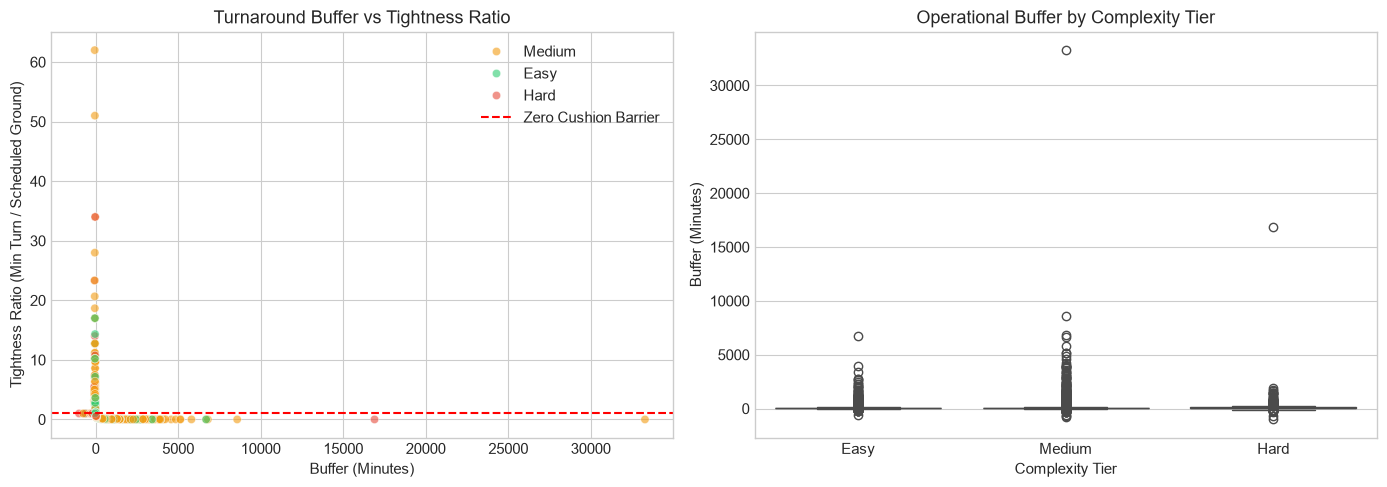

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=df,
    x='buffer_minutes',
    y='turnaround_tightness_ratio',
    hue='complexity_class',
    palette={'Easy': '#2ECC71', 'Medium': '#F39C12', 'Hard': '#E74C3C'},
    alpha=0.6,
    ax=axes[0]
)
axes[0].set_title('Turnaround Buffer vs Tightness Ratio')
axes[0].set_xlabel('Buffer (Minutes)')
axes[0].set_ylabel('Tightness Ratio (Min Turn / Scheduled Ground)')
axes[0].axhline(1.0, color='red', linestyle='--', label='Zero Cushion Barrier')
axes[0].legend()

sns.boxplot(
    data=df,
    x='complexity_class',
    y='buffer_minutes',
    order=['Easy', 'Medium', 'Hard'],
    palette={'Easy': '#2ECC71', 'Medium': '#F39C12', 'Hard': '#E74C3C'},
    ax=axes[1]
)
axes[1].set_title('Operational Buffer by Complexity Tier')
axes[1].set_xlabel('Complexity Tier')
axes[1].set_ylabel('Buffer (Minutes)')

plt.tight_layout()
plt.show()


## 4. Special Service Request (SSR) Impact on Flight Complexity
Flights with higher wheelchair assistance density require pre-boarding logistics and ground crew escorts.


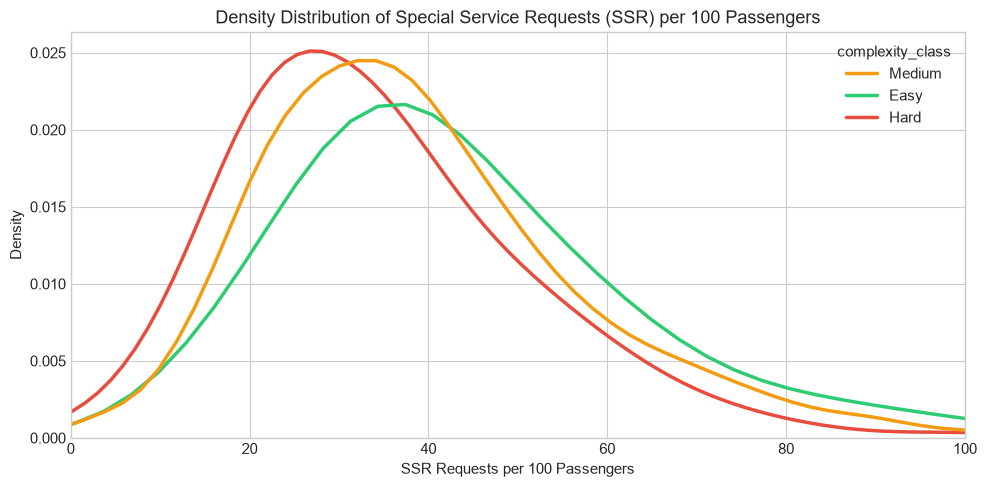

In [5]:
plt.figure(figsize=(10, 5))
sns.kdeplot(
    data=df,
    x='ssr_per_100_pax',
    hue='complexity_class',
    common_norm=False,
    palette={'Easy': '#2ECC71', 'Medium': '#F39C12', 'Hard': '#E74C3C'},
    linewidth=2.5
)
plt.title('Density Distribution of Special Service Requests (SSR) per 100 Passengers')
plt.xlabel('SSR Requests per 100 Passengers')
plt.ylabel('Density')
plt.xlim(0, 100)
plt.tight_layout()
plt.show()


## 5. Summary & Transition to Machine Learning
We now have a clean, 81-feature dataset saved to `data/processed/enriched_flight_complexity.csv` ready for statistical validation and machine learning classification.
